In [2]:
# =================================
# STUDENTS PERFORMANCE ANALYSIS
# =================================


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======== LOAD DATA ========

df = pd.read_csv('student_data.csv')

In [4]:
# ========== DATA VIEW & UNDERSTANDING =========

df.head(10)   

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [5]:
df.tail(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
385,MS,F,18,R,GT3,T,2,2,at_home,other,...,5,3,3,1,3,4,2,10,9,10
386,MS,F,18,R,GT3,T,4,4,teacher,at_home,...,4,4,3,2,2,5,7,6,5,6
387,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,0,7,5,0
388,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,0,7,9,8
389,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,0,6,5,0
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [6]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
df.shape

(395, 33)

In [8]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [10]:
# ========= DATA CLEANING ============

In [11]:
# Find Missing Values.

df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [12]:
# Find Duplicate values.

df.duplicated().sum()

np.int64(0)

In [13]:
# Remove Duplicates.

df.drop_duplicates(inplace=True)

In [14]:
# Remove Completely Empty Rows.

df.dropna(how="all", inplace=True)

In [15]:
# Reset Index.

df.reset_index(drop=True, inplace=True)

In [16]:
# =============== ADD NEW COLUMNS ==============#

In [17]:
# Find Performance Category.
 
df['performance'] = np.where(
    df['G3'] >= 15, 'Excellent',
    np.where(df['G3'] >= 10, 'Average', 'Poor')
)

print("\nAfter")
print(df)



After
    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... freetime goout  Dalc  Walc  health 

In [18]:
# Pass and Fail Status.

df['Status'] = np.where(df['G3'] >= 10, 'Pass', 'Fail')

print("\nAfter")
print(df)


After
    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... goout Dalc  Walc  health  absences 

In [19]:
# Attendance Category.

df['Attendance'] = np.where(df['absences'] <= 5,
                             'Good Attendance',
                             'Poor Attendance'
                             )

print("\nAfter")
print(df)
# df.tail(5)


After
    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... Dalc Walc  health  absences  G1  G2

In [20]:
# ============= DATA ANALYSIS & INSIGHTS ===============

In [21]:
# Total number of students.

df.shape[0]

print("\n TOTAL STUDENTS :", df.shape[0])


 TOTAL STUDENTS : 395


In [22]:
# Overall Average student performance.

df['G3'].mean()

print("\n AVERAGE FINAL GRADE:", df['G3'].mean())


 AVERAGE FINAL GRADE: 10.415189873417722


In [23]:
# Which school has the highest average grade.

Higest_grade = df.groupby('school')['G3'].mean()

print("\n HIGHEST AVG GRADE SCHOOL :")
print(Higest_grade. idxmax())
print(Higest_grade.max())



 HIGHEST AVG GRADE SCHOOL :
GP
10.489971346704872


In [24]:
# Gender-wise performance.

Gender = df.groupby('sex')['G3'].mean()

print("HIGHEST AVERAGE GRADE GENDER:", Gender.idxmax())
print("AVERAGE GRADE:", Gender.max())

HIGHEST AVERAGE GRADE GENDER: M
AVERAGE GRADE: 10.914438502673796


In [25]:
# Age-wise Performane.

Age = df.groupby('age')['G3'].mean()

print("BEST PERFORMED AGE GROUP :", Age.max())



BEST PERFORMED AGE GROUP : 14.0


In [26]:
# Study Time-wise Performance.

study_time = df.groupby('studytime')['G3'].mean()

print("STUDY TIME WISE PERFORMANCE:",study_time.max())

STUDY TIME WISE PERFORMANCE: 11.4


In [27]:
# Pass vs Fail Students.

Pass_count = (df['G3'] >= 10).sum()
Fail_count = (df['G3'] < 10).sum()

print("No of passing Students :", Pass_count)
print("No of Failed Students :", Fail_count)


No of passing Students : 265
No of Failed Students : 130


In [28]:
# Top 10 Highest performing students.

Top_students = df[['school', 'sex', 'G3']].sort_values(
    by='G3',
    ascending=False
).head(10)

print(("\n TOP 10 HIGHEST STUDENTS:"),Top_students)


 TOP 10 HIGHEST STUDENTS:     school sex  G3
47      GP   M  20
286     GP   F  19
374     MS   F  19
110     GP   M  19
8       GP   M  19
113     GP   M  19
91      GP   F  18
42      GP   M  18
36      GP   M  18
104     GP   M  18


In [29]:
# Find top perform School.

top_perform_school = df.groupby('school')['G3'].mean()

print("TOP PERFORM SCHOOL :", top_perform_school)

TOP PERFORM SCHOOL : school
GP    10.489971
MS     9.847826
Name: G3, dtype: float64


In [56]:
#============ NUMPY ANALYSIS==========#

In [57]:
print("\n NUMPY ANALYSIS :")
print("Average Final Grade:", np.mean(df['G3']))
print("Highest Final Grade :", np.max(df['G3']))
print("Lowest Final Grade:", np.min(df['G3']))
print("Median Final Grade:",np.median(df['G3']))
print("Number of students Passed :", np.sum(df['G3'] >=10))
print("Number of students Failed :", np.sum(df['G3'] < 10))
print(" Number of Excellent students :", np.sum(df['G3'] >= 15))


 NUMPY ANALYSIS :
Average Final Grade: 10.415189873417722
Highest Final Grade : 20
Lowest Final Grade: 0
Median Final Grade: 11.0
Number of students Passed : 265
Number of students Failed : 130
 Number of Excellent students : 73


In [30]:
# =================
# VISUALIZATION
# =================

<function matplotlib.pyplot.show(close=None, block=None)>

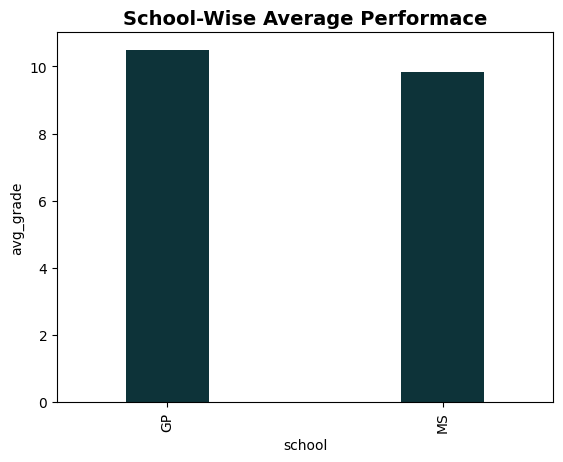

In [31]:
# WHICH SCHOOL HAS THE HIGHEST AVERAGE GRADE.
#========== BAR CHART=============

top_perform_school = df.groupby('school')['G3'].mean()

top_perform_school.plot(kind='bar',color="#0d3339",width=0.3)
plt.Figure(figsize=(8,4))
plt.title('School-Wise Average Performace', color="#000000",fontsize=14, fontweight='bold')
plt.xlabel('school')
plt.ylabel('avg_grade')
plt.show


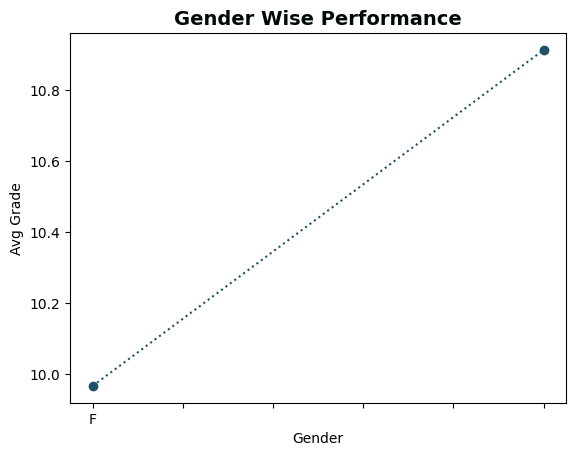

In [36]:
# COMPARE BOYS AND GIRLS PERFORMANCE
#========== LINE CHART=============

Gender = df.groupby('sex')['G3'].mean()

Gender.plot(kind='line',
            linestyle='dotted',
            marker='o',
            color="#1d5266")

plt.title('Gender Wise Performance', color="#010A04",fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Avg Grade')
plt.show()


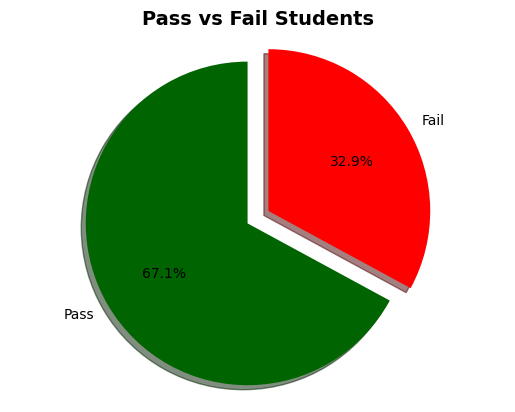

In [33]:
# PERCENTAGE OF STUDENTS WHO PASSED AND FAILED.
#=========== PIE CHART =========#

status_count = df['Status'].value_counts()
colors = ['darkgreen','red']
explode =(0,0.15)

plt.Figure(figsize=(6,6))
plt.pie (
     status_count,
     labels=status_count.index,
     autopct='%1.1f%%',
     colors=colors,
     explode=explode,
     shadow=True,
     startangle=90
     )
plt.title('Pass vs Fail Students',fontsize=14, fontweight='bold')
plt.axis('equal')  # Makes pie chart a circle
plt.show()

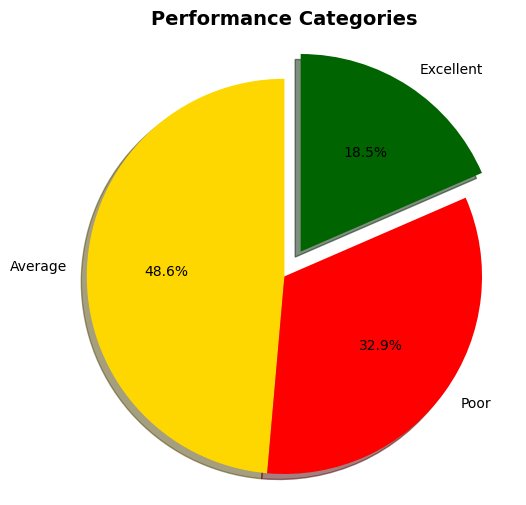

In [37]:
# STUDENTS PERFORMANCE CATEGORY.
#========= PIE CHART ========#

performance = df['performance'].value_counts()

colors = ['gold', 'red', 'darkgreen']
explode = (0, 0, 0.15)

plt.figure(figsize=(6,6))

plt.pie(
    performance,
    labels=performance.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)

plt.title('Performance Categories', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

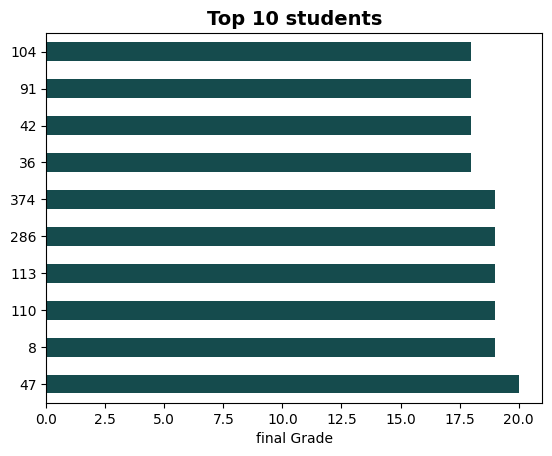

In [38]:
# IDENTIFY THE HIGHEST PERFORMING STUDENTS.
#========= BARH CHART ========#

top_10 = df.nlargest(10,'G3')

top_10['G3'].plot(kind='barh', color="#154b4d")
plt.title('Top 10 students', fontsize=14, fontweight='bold')
plt.xlabel('final Grade')
plt.show()


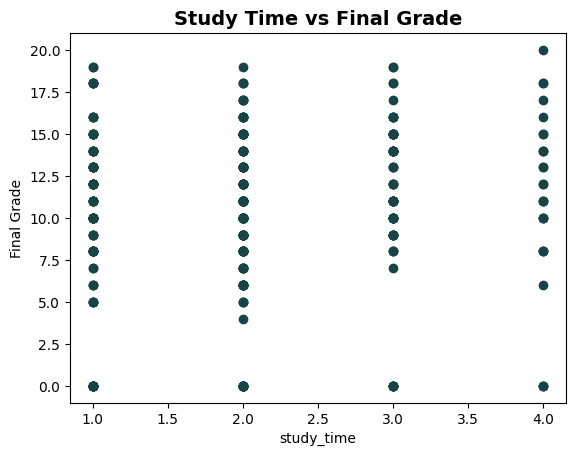

In [58]:
# STUDY TIME VS FINAL GRADE.
#======SCATTER CHART=======

plt.scatter(df['studytime'],df['G3'], color="#184445")

plt.title('Study Time vs Final Grade',fontsize=14, fontweight='bold')
plt.xlabel('study_time')
plt.ylabel('Final Grade')
plt.show()

In [60]:
#============= SAVE REPORT============

df.to_csv(" Final_Students_Performance-Analysis.csv", index=False)

print("\n REPORT SAVED SUCCESSFULLY")


 REPORT SAVED SUCCESSFULLY
